## Steps

shift+tab for parameters

- install and import relevant libraries
- load the dataset
- separate your dataset into independent and dependent features
- split data into train and test
- model training (linear regression)
- model prediction
- model evaluation

In [1]:
!pip install scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [33]:
df=pd.read_csv('EDA_Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


### Separate your dataset into independent and dependent features

In [34]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [36]:
y=df['price']
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [38]:
yes_no_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [40]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

In [45]:
X = df[['area','bedrooms','bathrooms','stories',
        'mainroad','guestroom','basement',
        'hotwaterheating','airconditioning',
        'parking','prefarea',
        'furnishingstatus_semi-furnished',
        'furnishingstatus_unfurnished']]

X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,2910,3,1,1,0,0,0,0,0,0,0,False,False


In [39]:
df[yes_no_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


### Split data into Train and Test

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)    ## shuffle by default true hi rehne do as it will take random values

In [47]:
X_train


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,0,0,1,1,0,False,False
93,7200,3,2,1,1,0,1,0,1,3,0,True,False
335,3816,2,1,1,1,0,1,0,1,2,0,False,False
412,2610,3,1,2,1,0,1,0,0,0,1,False,True
471,3750,3,1,2,1,0,0,0,0,0,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,False,True
106,5450,4,2,1,1,0,1,0,1,0,1,True,False
270,4500,3,2,3,1,0,0,1,0,1,0,False,False
435,4040,2,1,1,1,0,0,0,0,0,0,False,True


In [48]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,0,0,1,0,0,1,0,False,True
77,6500,3,2,3,1,0,0,0,1,0,1,False,False
360,4040,2,1,1,1,0,0,0,0,0,0,True,False
90,5000,3,1,2,1,0,0,0,1,0,0,True,False
493,3960,3,1,1,1,0,0,0,0,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,True,False
357,6930,4,1,2,0,0,0,0,0,1,0,False,False
39,6000,4,2,4,1,0,0,0,1,1,0,True,False
54,6000,3,2,2,1,1,0,0,1,1,0,True,False


In [49]:
y_train

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 436, dtype: int64

In [50]:
y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

In [51]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 436 entries, 46 to 102
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   area                             436 non-null    int64
 1   bedrooms                         436 non-null    int64
 2   bathrooms                        436 non-null    int64
 3   stories                          436 non-null    int64
 4   mainroad                         436 non-null    int64
 5   guestroom                        436 non-null    int64
 6   basement                         436 non-null    int64
 7   hotwaterheating                  436 non-null    int64
 8   airconditioning                  436 non-null    int64
 9   parking                          436 non-null    int64
 10  prefarea                         436 non-null    int64
 11  furnishingstatus_semi-furnished  436 non-null    bool 
 12  furnishingstatus_unfurnished     436 non-null    bool 

### Model Training (Linear Regression)

In [52]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
model.coef_   # calculate slopes

array([ 2.35968805e+02,  7.67787016e+04,  1.09444479e+06,  4.07476595e+05,
        3.67919948e+05,  2.31610037e+05,  3.90251176e+05,  6.84649885e+05,
        7.91426736e+05,  2.24841913e+05,  6.29890565e+05, -1.26881818e+05,
       -4.13645062e+05])

In [66]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [70]:
pd.DataFrame(model.coef_,index=X.columns,columns=['Coefficients/Slope'])

,Coefficients/Slope
area,2.359688e+02
bedrooms,7.677870e+04
bathrooms,1.094445e+06
stories,4.074766e+05
mainroad,3.679199e+05
guestroom,2.316100e+05
basement,3.902512e+05
hotwaterheating,6.846499e+05
airconditioning,7.914267e+05
parking,2.248419e+05


In [55]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,0,0,1,1,0,False,False
93,7200,3,2,1,1,0,1,0,1,3,0,True,False
335,3816,2,1,1,1,0,1,0,1,2,0,False,False
412,2610,3,1,2,1,0,1,0,0,0,1,False,True
471,3750,3,1,2,1,0,0,0,0,0,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,False,True
106,5450,4,2,1,1,0,1,0,1,0,1,True,False
270,4500,3,2,3,1,0,0,1,0,1,0,False,False
435,4040,2,1,1,1,0,0,0,0,0,0,False,True


In [56]:
y_train

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 436, dtype: int64

### Model Prediction

In [57]:
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

In [58]:
X_train[:3]     

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,0,0,1,1,0,False,False
93,7200,3,2,1,1,0,1,0,1,3,0,True,False
335,3816,2,1,1,1,0,1,0,1,2,0,False,False


In [59]:
y_train[:3]    # Actual

46     7525000
93     6300000
335    3920000
Name: price, dtype: int64

In [60]:
y_pred_train[:3]    # Predicted

array([7109165.83869915, 6882951.80434333, 4815249.78634875])

In [61]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,2910,3,1,1,0,0,0,0,0,0,0,False,False


In [62]:
X_test[:3]

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,0,0,1,0,0,1,0,False,True
77,6500,3,2,3,1,0,0,0,1,0,1,False,False
360,4040,2,1,1,1,0,0,0,0,0,0,True,False


In [63]:
y_test[:3]

316    4060000
77     6650000
360    3710000
Name: price, dtype: int64

In [64]:
y_pred_test[:3]

array([5164653.90033967, 7224722.29802166, 3109863.24240338])

### Model Evaluation

In [71]:
mean_squared_error(y_train,y_pred_train)

968358188440.7242

In [72]:
np.sqrt(mean_squared_error(y_train,y_pred_train))

np.float64(984051.9236507412)

In [73]:
mean_absolute_error(y_train,y_pred_train)

719242.8936724719

In [74]:
r2_score(y_train,y_pred_train)

0.6859438988560158

In [75]:
r2_score(y_test,y_pred_test)

0.6529242642153187

In [100]:
# Training Evaluation
def training_evaluation(actual,predicted):
    mse=mean_squared_error(actual,predicted)
    rmse=np.sqrt(mean_squared_error(actual,predicted))
    mae=mean_absolute_error(actual,predicted)
    r2=r2_score(actual,predicted)

    print(f'MSE : {mse}')
    print(f'RMSE : {rmse}')
    print(f'MAE : {mae}')
    print(f'R2_Score : {r2}')

    plt.scatter(actual,predicted,color='k')
    plt.plot([actual.min(),actual.max()],[actual.min(),actual.max()],color='r',ls='--',lw=3)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Best Fit Line')
    plt.show()

MSE : 968358188440.7242
RMSE : 984051.9236507412
MAE : 719242.8936724719
R2_Score : 0.6859438988560158


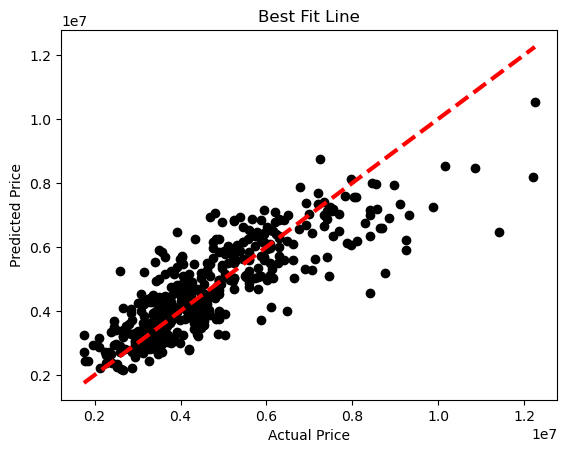

In [101]:
training_evaluation(y_train,y_pred_train)

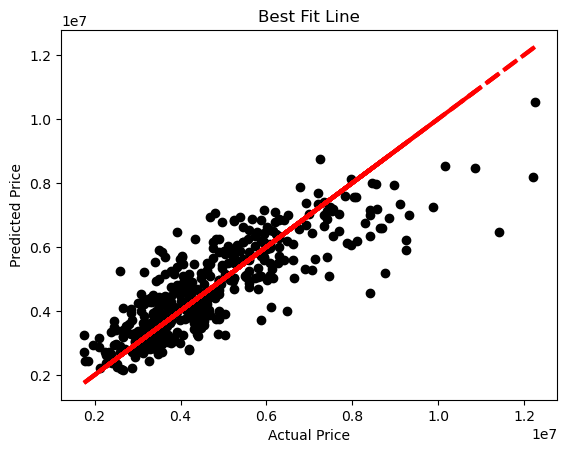

In [98]:
plt.scatter(y_train,y_pred_train,color='k')
plt.plot([y_train,y_pred_train],[y_train,y_pred_train],color='r',ls='--',lw=3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Best Fit Line')
plt.show()

In [105]:
# Test Evaluation
def test_evaluation(actual,predicted):
    mse=mean_squared_error(actual,predicted)
    rmse=np.sqrt(mean_squared_error(actual,predicted))
    mae=mean_absolute_error(actual,predicted)
    r2=r2_score(actual,predicted)

    print(f'MSE : {mse}')
    print(f'RMSE : {rmse}')
    print(f'MAE : {mae}')
    print(f'R2_Score : {r2}')

    plt.scatter(actual,predicted,color='b')
    plt.plot([actual.min(),actual.max()],[actual.min(),actual.max()],color='g',ls='--',lw=3)   
    # to cover full range, we use min and max and to draw diagonal line
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Best Fit Line')
    plt.show()

MSE : 1754318687330.6624
RMSE : 1324506.9600914381
MAE : 970043.4039201637
R2_Score : 0.6529242642153187


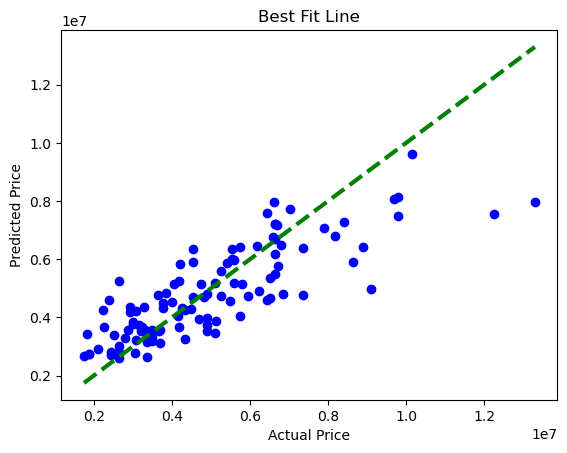

In [106]:
test_evaluation(y_test,y_pred_test)

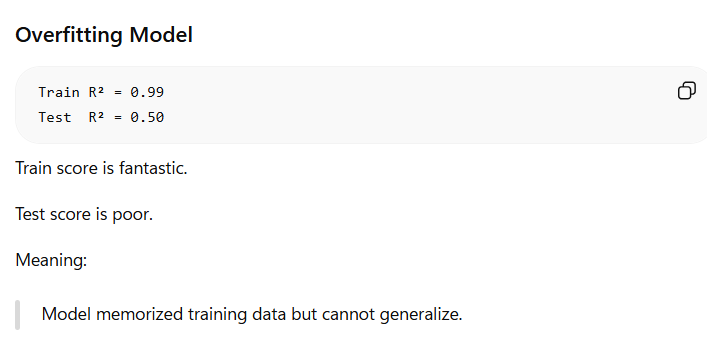

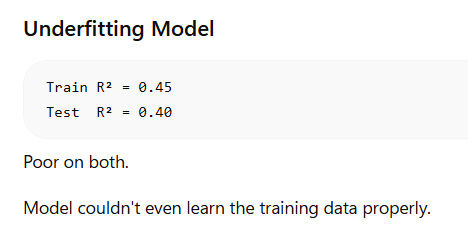

### Need of Splitting
To evaluate the model on unseen data and check its generalization ability. Training data is used to learn patterns, while test data is used to measure how well the model performs on new data and to detect overfitting.

- Train high, Test low → Overfitting
- Train low, Test low → Underfitting
- Train and Test close → Good fit / Properly fitted model